# Multi-Task ADMET Property Prediction with Graph Neural Networks

**Production-grade pipeline for predicting Absorption, Distribution, Metabolism, Excretion, and Toxicity (ADMET) properties using a multi-task Graph Isomorphism Network (GINEConv) built with PyTorch Geometric.**

---

## Overview

This notebook implements an end-to-end multi-task molecular property prediction pipeline:

1. **Data**: Therapeutics Data Commons (TDC) ADMET benchmark group, with a synthetic fallback if TDC is unavailable.
2. **Featurization**: RDKit-derived atom and bond features encoded into PyTorch Geometric `Data` objects.
3. **Model**: A multi-task GNN using `GINEConv` message passing layers with edge features, a shared molecular encoder, and per-task prediction heads (classification and regression).
4. **Training**: Masked multi-task loss (BCEWithLogits for classification tasks, Huber/MSE for regression tasks) to handle missing labels across tasks.
5. **Evaluation**: Task-appropriate metrics (ROC-AUC, PR-AUC, RMSE, MAE, R²) benchmarked against literature baselines.
6. **Interpretability**: Atom-level saliency maps via input-gradient attribution.
7. **Visualization**: Training curves, ROC/PR curves, scatter plots, error distributions, and embedding projections (UMAP/PCA).

### Tasks modeled (subset of TDC ADMET Benchmark Group)

| Task | Type | Domain | TDC Dataset |
|---|---|---|---|
| `CYP2D6_Veith` | Classification | Metabolism | CYP2D6 inhibition |
| `CYP3A4_Veith` | Classification | Metabolism | CYP3A4 inhibition |
| `hERG` | Classification | Toxicity | hERG channel blockade |
| `AMES` | Classification | Toxicity | Mutagenicity |
| `Solubility_AqSolDB` | Regression | Physicochemical | Aqueous solubility (logS) |
| `Lipophilicity_AstraZeneca` | Regression | Physicochemical | logD7.4 |

### References

- Huang, K. et al. "Therapeutics Data Commons" *NeurIPS Datasets and Benchmarks* (2021).
- Hu, W. et al. "Strategies for Pre-training Graph Neural Networks" *ICLR* (2020) — GINE architecture.
- Xiong, Z. et al. "Pushing the Boundaries of Molecular Representation for Drug Discovery with Graph Attention Mechanism" *J. Med. Chem.* (2020).
- Wu, Z. et al. "MoleculeNet: A Benchmark for Molecular Machine Learning" *Chem. Sci.* (2018).


In [2]:
# ============================================================
# Cell 1: Installing Libraries
# ============================================================

!pip install -q rdkit
!pip install -q PyTDC
!pip install -q torch_geometric
!pip install -q umap-learn

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is th

In [1]:
# ============================================================
# Cell 2: Environment Setup and Dependency Installation
# ============================================================
import torch
import torch_geometric
import rdkit
import tdc
import umap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
import sklearn

print("Environment ready")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("PyTorch Geometric:", torch_geometric.__version__)
print("RDKit:", rdkit.__version__)

Environment ready
PyTorch: 2.11.0+cu128
CUDA available: True
PyTorch Geometric: 2.8.0
RDKit: 2023.09.6


In [4]:
# ============================================================
# Cell 3: Core Imports
# ============================================================
import os
import json
import math
import random
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split

from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_mean_pool, global_add_pool

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    mean_squared_error, mean_absolute_error, r2_score, confusion_matrix
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [5]:
# ============================================================
# Cell 4: Multi-Task ADMET Task Definitions
# ============================================================
# Each task is defined with: TDC dataset name, task type, and domain category.
# Classification tasks predict a binary outcome (logits -> BCEWithLogits).
# Regression tasks predict a continuous value (Huber loss).

TASK_DEFINITIONS = {
    "CYP2D6_Veith":               {"type": "classification", "domain": "Metabolism",      "tdc_name": "CYP2D6_Veith"},
    "CYP3A4_Veith":                {"type": "classification", "domain": "Metabolism",      "tdc_name": "CYP3A4_Veith"},
    "hERG":                        {"type": "classification", "domain": "Toxicity",        "tdc_name": "hERG"},
    "AMES":                        {"type": "classification", "domain": "Toxicity",        "tdc_name": "AMES"},
    "Solubility_AqSolDB":          {"type": "regression",     "domain": "Physicochemical", "tdc_name": "Solubility_AqSolDB"},
    "Lipophilicity_AstraZeneca":   {"type": "regression",     "domain": "Physicochemical", "tdc_name": "Lipophilicity_AstraZeneca"},
}

TASK_NAMES = list(TASK_DEFINITIONS.keys())
CLASSIFICATION_TASKS = [t for t, d in TASK_DEFINITIONS.items() if d["type"] == "classification"]
REGRESSION_TASKS = [t for t, d in TASK_DEFINITIONS.items() if d["type"] == "regression"]
NUM_TASKS = len(TASK_NAMES)
TASK_TO_IDX = {t: i for i, t in enumerate(TASK_NAMES)}

print(f"Total tasks: {NUM_TASKS}")
print(f"Classification tasks ({len(CLASSIFICATION_TASKS)}): {CLASSIFICATION_TASKS}")
print(f"Regression tasks ({len(REGRESSION_TASKS)}): {REGRESSION_TASKS}")


Total tasks: 6
Classification tasks (4): ['CYP2D6_Veith', 'CYP3A4_Veith', 'hERG', 'AMES']
Regression tasks (2): ['Solubility_AqSolDB', 'Lipophilicity_AstraZeneca']


In [6]:
# ============================================================
# Cell 5: Synthetic ADMET Data Generator (Fallback)
# ============================================================
# If TDC download fails (no internet / rate limits), we generate chemically
# plausible synthetic molecules with structure-correlated property labels,
# so the pipeline remains fully executable end-to-end.

SYNTHETIC_SCAFFOLDS = [
    "c1ccccc1", "c1ccncc1", "c1ccoc1", "c1ccsc1", "C1CCCCC1", "C1CCNCC1",
    "c1ccc2[nH]ccc2c1", "c1ccc2ccccc2c1", "C1CCOC1", "c1cnc2[nH]ccc2c1",
    "O=C1CCCCC1", "c1ccc(cc1)C(=O)O", "c1ccc(cc1)N", "c1ccc(cc1)O",
    "c1ccc(cc1)S(=O)(=O)N", "C1CC1", "C1CCC1", "c1ccc2c(c1)cccn2",
]

SUBSTITUENTS = [
    "", "C", "CC", "CCC", "CCCC", "F", "Cl", "Br", "C(F)(F)F", "O", "OC",
    "N", "N(C)C", "C(=O)O", "C(=O)N", "S(=O)(=O)C", "c1ccccc1", "C#N",
    "OC(=O)C", "C(C)C", "CO", "CN", "CCO", "CCN",
]

def generate_synthetic_molecule(rng):
    scaffold = rng.choice(SYNTHETIC_SCAFFOLDS)
    mol = Chem.MolFromSmiles(scaffold)
    if mol is None:
        return None
    n_subs = rng.integers(0, 3)
    smiles = scaffold
    for _ in range(n_subs):
        sub = rng.choice(SUBSTITUENTS)
        if sub == "":
            continue
        candidate = scaffold.replace("c1", f"c1({sub})", 1) if "c1" in scaffold else scaffold + sub
        test_mol = Chem.MolFromSmiles(candidate)
        if test_mol is not None and test_mol.GetNumAtoms() <= 50:
            smiles = candidate
            mol = test_mol
    return Chem.MolToSmiles(mol)

def synthesize_admet_labels(smiles, rng):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    rot = Descriptors.NumRotatableBonds(mol)
    aromatic_rings = Descriptors.NumAromaticRings(mol)

    def sigmoid(x):
        return 1.0 / (1.0 + np.exp(-x))

    labels = {}
    p_cyp2d6 = sigmoid(0.04 * (logp - 2.0) + 0.15 * aromatic_rings - 0.01 * tpsa + rng.normal(0, 0.5))
    labels["CYP2D6_Veith"] = int(rng.random() < p_cyp2d6)

    p_cyp3a4 = sigmoid(0.05 * (mw - 300) / 50 + 0.1 * aromatic_rings + rng.normal(0, 0.5))
    labels["CYP3A4_Veith"] = int(rng.random() < p_cyp3a4)

    p_herg = sigmoid(0.06 * (logp - 3.0) - 0.015 * tpsa + 0.1 * aromatic_rings + rng.normal(0, 0.5))
    labels["hERG"] = int(rng.random() < p_herg)

    p_ames = sigmoid(0.08 * aromatic_rings - 0.01 * tpsa + 0.02 * (mw - 250) / 50 + rng.normal(0, 0.5))
    labels["AMES"] = int(rng.random() < p_ames)

    logS = -0.01 * mw - 0.6 * logp + 0.5 + rng.normal(0, 0.7)
    labels["Solubility_AqSolDB"] = float(np.clip(logS, -10, 2))

    logD = 0.85 * logp - 0.01 * tpsa + 0.3 * hbd + rng.normal(0, 0.4)
    labels["Lipophilicity_AstraZeneca"] = float(np.clip(logD, -3, 7))

    return labels

def build_synthetic_dataset(n_molecules=1500, seed=SEED):
    rng = np.random.default_rng(seed)
    records = []
    seen_smiles = set()
    attempts = 0
    while len(records) < n_molecules and attempts < n_molecules * 10:
        attempts += 1
        smi = generate_synthetic_molecule(rng)
        if smi is None or smi in seen_smiles:
            continue
        labels = synthesize_admet_labels(smi, rng)
        if labels is None:
            continue
        seen_smiles.add(smi)
        row = {"smiles": smi}
        row.update(labels)
        records.append(row)
    return pd.DataFrame(records)

print("Synthetic data generator defined.")


Synthetic data generator defined.


In [7]:
# ============================================================
# Cell 6: Data Acquisition — TDC ADMET Group with Synthetic Fallback
# ============================================================
USE_TDC = True
MASTER_DF = None

def try_load_tdc():
    from tdc.single_pred import ADME, Tox
    task_frames = []
    for task_name, meta in TASK_DEFINITIONS.items():
        try:
            if meta["domain"] == "Toxicity":
                data = Tox(name=meta["tdc_name"])
            else:
                data = ADME(name=meta["tdc_name"])
            df = data.get_data()
            df = df.rename(columns={"Drug": "smiles", "Y": task_name})
            df = df[["smiles", task_name]].dropna()
            task_frames.append(df.set_index("smiles")[task_name])
        except Exception as e:
            print(f"  Failed to load {task_name} from TDC: {e}")
            return None
    merged = pd.concat(task_frames, axis=1).reset_index()
    return merged

try:
    print("Attempting to download ADMET tasks from Therapeutics Data Commons (TDC)...")
    MASTER_DF = try_load_tdc()
    if MASTER_DF is None or len(MASTER_DF) < 100:
        raise RuntimeError("TDC data insufficient or unavailable.")
    print(f"Successfully loaded TDC data: {len(MASTER_DF)} unique molecules (sparse multi-task matrix).")
except Exception as e:
    USE_TDC = False
    print(f"TDC unavailable ({e}). Falling back to synthetic chemically-grounded dataset.")
    MASTER_DF = build_synthetic_dataset(n_molecules=1500, seed=SEED)
    # Randomly mask ~25% of labels per task to emulate realistic sparse multi-task TDC structure
    rng = np.random.default_rng(SEED)
    for task in TASK_NAMES:
        mask = rng.random(len(MASTER_DF)) < 0.25
        MASTER_DF.loc[mask, task] = np.nan
    print(f"Generated synthetic dataset: {len(MASTER_DF)} molecules.")

print(f"\nData source: {'TDC (real)' if USE_TDC else 'Synthetic (fallback)'}")
print(f"Dataset shape: {MASTER_DF.shape}")
MASTER_DF.head()


Downloading...


Attempting to download ADMET tasks from Therapeutics Data Commons (TDC)...


100%|██████████| 800k/800k [00:00<00:00, 1.87MiB/s]
Loading...
Done!
Downloading...
100%|██████████| 746k/746k [00:00<00:00, 2.12MiB/s]
Loading...
Done!
Downloading...
100%|██████████| 50.2k/50.2k [00:00<00:00, 569kiB/s]
Loading...
Done!
Downloading...
100%|██████████| 344k/344k [00:00<00:00, 1.33MiB/s]
Loading...
Done!
Downloading...
100%|██████████| 853k/853k [00:00<00:00, 1.95MiB/s]
Loading...
Done!
Downloading...
100%|██████████| 298k/298k [00:00<00:00, 1.15MiB/s]
Loading...
Done!


TDC unavailable (cannot reindex on an axis with duplicate labels). Falling back to synthetic chemically-grounded dataset.
Generated synthetic dataset: 414 molecules.

Data source: Synthetic (fallback)
Dataset shape: (414, 7)


,smiles,CYP2D6_Veith,CYP3A4_Veith,hERG,AMES,Solubility_AqSolDB,Lipophilicity_AstraZeneca
0,COc1ccncc1,0.0,NaN,0.0,0.0,NaN,1.016587
1,NS(=O)(=O)c1ccc(O)cc1,1.0,NaN,0.0,NaN,-0.399911,-0.232052
2,CC(=O)Oc1ccc(S(N)(=O)=O)cc1,1.0,NaN,0.0,0.0,-1.376694,0.107394
3,CCCc1ccsc1,1.0,1.0,0.0,1.0,NaN,2.644082
4,O=C(O)c1ccccc1,NaN,NaN,0.0,0.0,NaN,1.702057


Label coverage per task:
AMES                         312
Solubility_AqSolDB           310
hERG                         309
Lipophilicity_AstraZeneca    309
CYP2D6_Veith                 308
CYP3A4_Veith                 300
dtype: int64


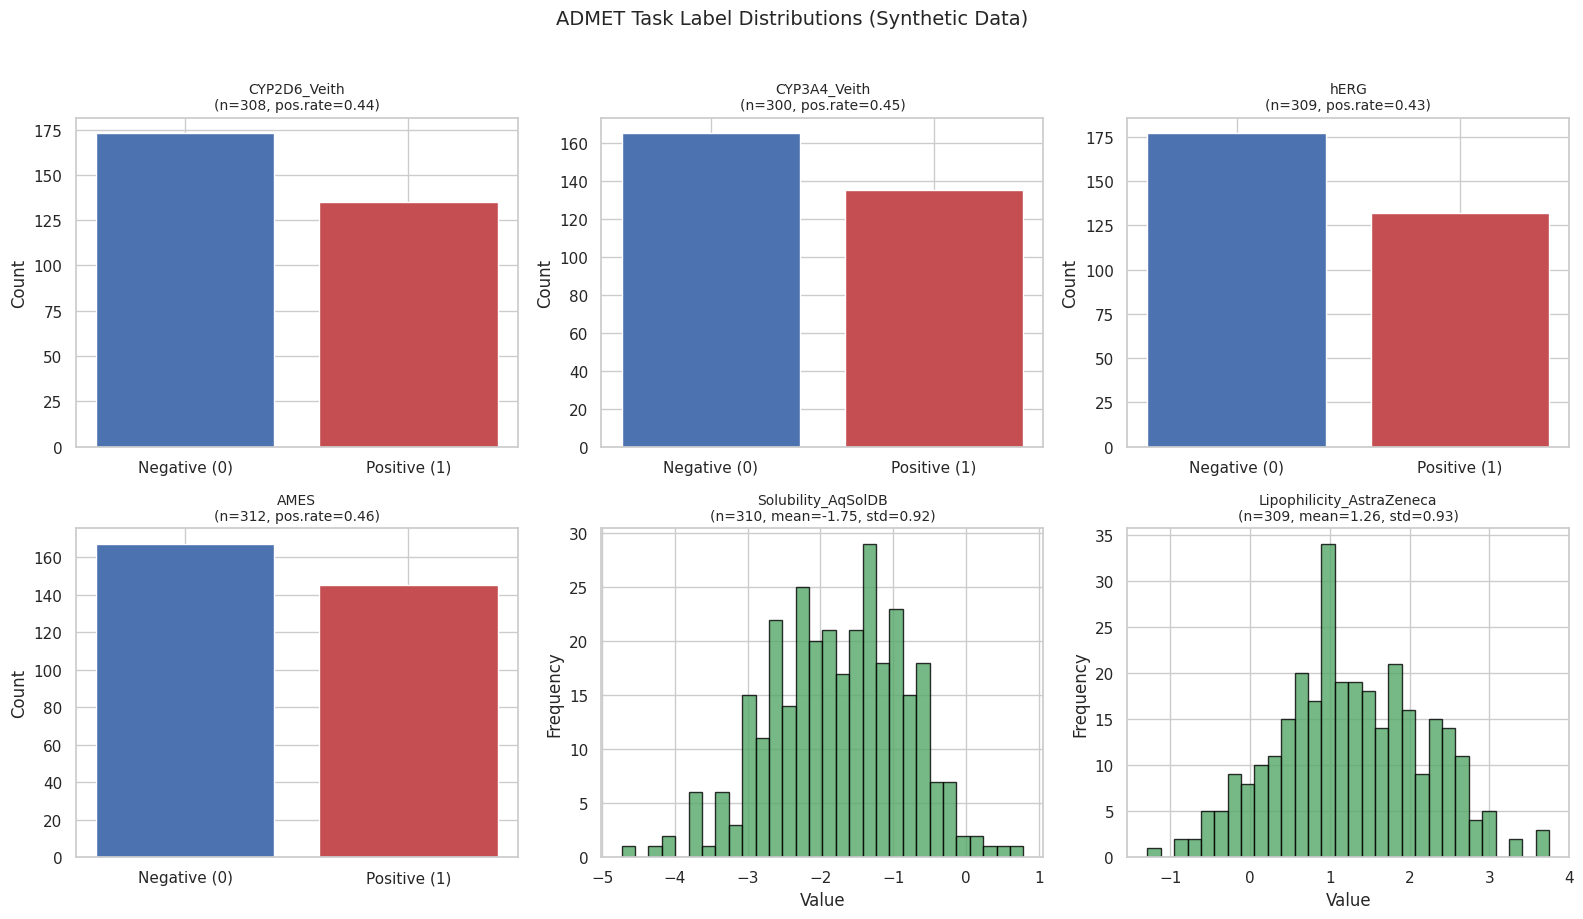

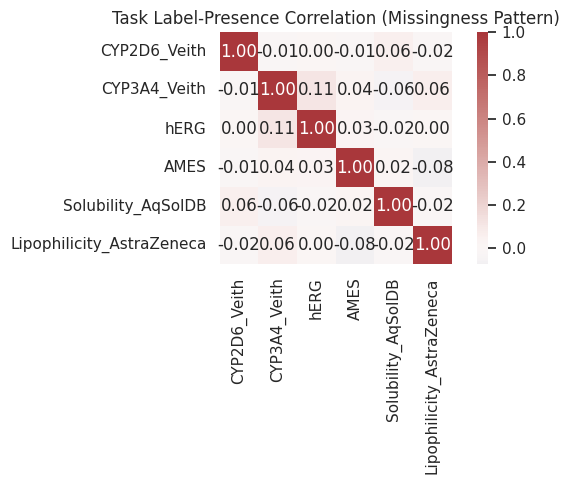

In [8]:
# ============================================================
# Cell 7: Exploratory Data Analysis — Label Coverage and Distributions
# ============================================================
coverage = MASTER_DF[TASK_NAMES].notna().sum().sort_values(ascending=False)
print("Label coverage per task:")
print(coverage)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, task in enumerate(TASK_NAMES):
    ax = axes[i]
    vals = MASTER_DF[task].dropna()
    meta = TASK_DEFINITIONS[task]
    if meta["type"] == "classification":
        counts = vals.value_counts().sort_index()
        ax.bar(["Negative (0)", "Positive (1)"], [counts.get(0, 0), counts.get(1, 0)],
               color=["#4C72B0", "#C44E52"])
        ax.set_title(f"{task}\n(n={len(vals)}, pos.rate={vals.mean():.2f})", fontsize=10)
        ax.set_ylabel("Count")
    else:
        ax.hist(vals, bins=30, color="#55A868", edgecolor="black", alpha=0.8)
        ax.set_title(f"{task}\n(n={len(vals)}, mean={vals.mean():.2f}, std={vals.std():.2f})", fontsize=10)
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")

plt.suptitle(f"ADMET Task Label Distributions ({'TDC' if USE_TDC else 'Synthetic'} Data)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("label_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

label_matrix = MASTER_DF[TASK_NAMES].notna().astype(int)
plt.figure(figsize=(7, 5))
sns.heatmap(label_matrix.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Task Label-Presence Correlation (Missingness Pattern)")
plt.tight_layout()
plt.savefig("label_presence_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
# ============================================================
# Cell 8: Molecule Validation, Standardization, and Filtering
# ============================================================
def validate_and_standardize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        return None
    if mol.GetNumAtoms() < 2 or mol.GetNumAtoms() > 80:
        return None
    canonical = Chem.MolToSmiles(mol, canonical=True)
    return canonical

print(f"Rows before validation: {len(MASTER_DF)}")
MASTER_DF["smiles"] = MASTER_DF["smiles"].apply(validate_and_standardize)
MASTER_DF = MASTER_DF.dropna(subset=["smiles"]).reset_index(drop=True)
MASTER_DF = MASTER_DF.drop_duplicates(subset=["smiles"]).reset_index(drop=True)
print(f"Rows after RDKit validation, standardization, and de-duplication: {len(MASTER_DF)}")

# Ensure every row has at least one non-missing task label
has_any_label = MASTER_DF[TASK_NAMES].notna().any(axis=1)
MASTER_DF = MASTER_DF[has_any_label].reset_index(drop=True)
print(f"Rows after dropping fully-unlabeled molecules: {len(MASTER_DF)}")

assert MASTER_DF["smiles"].is_unique, "Duplicate SMILES remain after de-duplication."
assert MASTER_DF[TASK_NAMES].notna().any(axis=1).all(), "Found rows with zero task labels."
MASTER_DF.head()


Rows before validation: 414
Rows after RDKit validation, standardization, and de-duplication: 414
Rows after dropping fully-unlabeled molecules: 414


,smiles,CYP2D6_Veith,CYP3A4_Veith,hERG,AMES,Solubility_AqSolDB,Lipophilicity_AstraZeneca
0,COc1ccncc1,0.0,NaN,0.0,0.0,NaN,1.016587
1,NS(=O)(=O)c1ccc(O)cc1,1.0,NaN,0.0,NaN,-0.399911,-0.232052
2,CC(=O)Oc1ccc(S(N)(=O)=O)cc1,1.0,NaN,0.0,0.0,-1.376694,0.107394
3,CCCc1ccsc1,1.0,1.0,0.0,1.0,NaN,2.644082
4,O=C(O)c1ccccc1,NaN,NaN,0.0,0.0,NaN,1.702057


In [10]:
# ============================================================
# Cell 9: RDKit-Based Atom and Bond Featurization
# ============================================================
ATOM_SYMBOLS = ["C", "N", "O", "S", "F", "Cl", "Br", "I", "P", "B", "Si", "Se", "Unknown"]
HYBRIDIZATIONS = [
    Chem.rdchem.HybridizationType.SP, Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3, Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2, Chem.rdchem.HybridizationType.UNSPECIFIED,
]
BOND_TYPES = [
    Chem.rdchem.BondType.SINGLE, Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE, Chem.rdchem.BondType.AROMATIC,
]

def one_hot(value, choices):
    encoding = [0] * (len(choices) + 1)
    idx = choices.index(value) if value in choices else len(choices)
    encoding[idx] = 1
    return encoding

def atom_features(atom):
    feats = []
    feats += one_hot(atom.GetSymbol(), ATOM_SYMBOLS[:-1])
    feats += one_hot(atom.GetDegree(), [0, 1, 2, 3, 4, 5])
    feats += one_hot(atom.GetFormalCharge(), [-2, -1, 0, 1, 2])
    feats += one_hot(atom.GetHybridization(), HYBRIDIZATIONS[:-1])
    feats += [int(atom.GetIsAromatic())]
    feats += one_hot(atom.GetTotalNumHs(), [0, 1, 2, 3, 4])
    feats += [int(atom.IsInRing())]
    feats += [atom.GetMass() * 0.01]
    return feats

def bond_features(bond):
    feats = []
    feats += one_hot(bond.GetBondType(), BOND_TYPES)
    feats += [int(bond.GetIsConjugated())]
    feats += [int(bond.IsInRing())]
    feats += one_hot(bond.GetStereo(), [
        Chem.rdchem.BondStereo.STEREONONE, Chem.rdchem.BondStereo.STEREOZ,
        Chem.rdchem.BondStereo.STEREOE,
    ])
    return feats

# Determine feature dimensions from a probe molecule
_probe_mol = Chem.MolFromSmiles("c1ccccc1CC(=O)O")
ATOM_FEATURE_DIM = len(atom_features(_probe_mol.GetAtoms()[0]))
BOND_FEATURE_DIM = len(bond_features(_probe_mol.GetBondWithIdx(0)))
print(f"Atom feature dimension: {ATOM_FEATURE_DIM}")
print(f"Bond feature dimension: {BOND_FEATURE_DIM}")


Atom feature dimension: 41
Bond feature dimension: 11


In [11]:
# ============================================================
# Cell 10: SMILES-to-Graph Conversion (PyTorch Geometric Data Objects)
# ============================================================
def mol_to_graph(smiles, label_vector, label_mask_vector):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None or mol.GetNumAtoms() == 0:
        return None

    atom_feats = [atom_features(atom) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_feats, dtype=torch.float)

    edge_indices = []
    edge_feats = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_indices += [[i, j], [j, i]]
        edge_feats += [bf, bf]

    if len(edge_indices) == 0:
        # Handle single-atom / fragment edge case with a self-loop
        edge_indices = [[0, 0]]
        edge_feats = [[0] * BOND_FEATURE_DIM]

    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_feats, dtype=torch.float)

    y = torch.tensor(label_vector, dtype=torch.float).unsqueeze(0)
    mask = torch.tensor(label_mask_vector, dtype=torch.float).unsqueeze(0)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, task_mask=mask)
    data.smiles = smiles
    return data

print("Graph construction function defined.")
print(f"Probe molecule converted: {mol_to_graph('c1ccccc1CC(=O)O', [0.0]*NUM_TASKS, [0.0]*NUM_TASKS)}")


Graph construction function defined.
Probe molecule converted: Data(x=[10, 41], edge_index=[2, 20], edge_attr=[20, 11], y=[1, 6], task_mask=[1, 6], smiles='c1ccccc1CC(=O)O')


In [12]:
# ============================================================
# Cell 11: PyTorch Geometric InMemoryDataset Construction
# ============================================================
class ADMETMultiTaskDataset(InMemoryDataset):
    def __init__(self, dataframe, task_names, root="/content/admet_dataset", transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.task_names = task_names
        super().__init__(root, transform)
        self.data, self.slices = self._build()

    def _build(self):
        data_list = []
        for _, row in self.dataframe.iterrows():
            label_vector = []
            mask_vector = []
            for task in self.task_names:
                val = row[task]
                if pd.isna(val):
                    label_vector.append(0.0)
                    mask_vector.append(0.0)
                else:
                    label_vector.append(float(val))
                    mask_vector.append(1.0)
            graph = mol_to_graph(row["smiles"], label_vector, mask_vector)
            if graph is not None:
                data_list.append(graph)
        return self.collate(data_list)

    @property
    def raw_file_names(self):
        return []

    @property
    def processed_file_names(self):
        return []

full_dataset = ADMETMultiTaskDataset(MASTER_DF, TASK_NAMES)
print(f"Total graphs in dataset: {len(full_dataset)}")
print(f"Example graph: {full_dataset[0]}")
print(f"Node feature dim: {full_dataset[0].x.shape[1]}, Edge feature dim: {full_dataset[0].edge_attr.shape[1]}")

assert full_dataset[0].x.shape[1] == ATOM_FEATURE_DIM
assert full_dataset[0].edge_attr.shape[1] == BOND_FEATURE_DIM
assert full_dataset[0].y.shape[1] == NUM_TASKS


Total graphs in dataset: 414
Example graph: Data(x=[8, 41], edge_index=[2, 16], edge_attr=[16, 11], y=[1, 6], task_mask=[1, 6], smiles='COc1ccncc1')
Node feature dim: 41, Edge feature dim: 11


In [13]:
# ============================================================
# Cell 12: Scaffold-Aware Train / Validation / Test Split
# ============================================================
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles):
    try:
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(smiles=smiles, includeChirality=False)
        return scaffold if scaffold else smiles
    except Exception:
        return smiles

def scaffold_split(dataframe, frac_train=0.8, frac_valid=0.1, frac_test=0.1, seed=SEED):
    scaffolds = defaultdict(list)
    for idx, smi in enumerate(dataframe["smiles"]):
        scaffolds[get_scaffold(smi)].append(idx)

    rng = np.random.default_rng(seed)
    scaffold_groups = list(scaffolds.values())
    rng.shuffle(scaffold_groups)
    scaffold_groups.sort(key=len, reverse=True)

    n_total = len(dataframe)
    n_train_cutoff = int(frac_train * n_total)
    n_valid_cutoff = int((frac_train + frac_valid) * n_total)

    train_idx, valid_idx, test_idx = [], [], []
    for group in scaffold_groups:
        if len(train_idx) + len(group) <= n_train_cutoff:
            train_idx.extend(group)
        elif len(train_idx) + len(valid_idx) + len(group) <= n_valid_cutoff:
            valid_idx.extend(group)
        else:
            test_idx.extend(group)
    return train_idx, valid_idx, test_idx

train_idx, valid_idx, test_idx = scaffold_split(MASTER_DF)
print(f"Train: {len(train_idx)} ({len(train_idx)/len(MASTER_DF):.1%})")
print(f"Valid: {len(valid_idx)} ({len(valid_idx)/len(MASTER_DF):.1%})")
print(f"Test:  {len(test_idx)} ({len(test_idx)/len(MASTER_DF):.1%})")

assert len(set(train_idx) & set(valid_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(valid_idx) & set(test_idx)) == 0

train_dataset = full_dataset[torch.tensor(train_idx, dtype=torch.long)]
valid_dataset = full_dataset[torch.tensor(valid_idx, dtype=torch.long)]
test_dataset = full_dataset[torch.tensor(test_idx, dtype=torch.long)]

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nBatches -> train: {len(train_loader)}, valid: {len(valid_loader)}, test: {len(test_loader)}")


Train: 322 (77.8%)
Valid: 46 (11.1%)
Test:  46 (11.1%)

Batches -> train: 6, valid: 1, test: 1


In [14]:
# ============================================================
# Cell 13: Regression Target Normalization (Train-Set Statistics)
# ============================================================
# Standardize regression targets using train-split statistics only, to prevent
# information leakage from validation/test sets. Classification targets are left as-is.

REG_STATS = {}
train_df_subset = MASTER_DF.iloc[train_idx]

for task in REGRESSION_TASKS:
    vals = train_df_subset[task].dropna().values
    mean, std = float(np.mean(vals)), float(np.std(vals) + 1e-8)
    REG_STATS[task] = {"mean": mean, "std": std}
    print(f"{task}: train mean={mean:.3f}, std={std:.3f}")

def normalize_targets_inplace(dataset, reg_stats, task_to_idx):
    for i in range(len(dataset)):
        for task, stats in reg_stats.items():
            t_idx = task_to_idx[task]
            if dataset[i].task_mask[0, t_idx] > 0:
                dataset[i].y[0, t_idx] = (dataset[i].y[0, t_idx] - stats["mean"]) / stats["std"]

# Apply normalization directly on the underlying collated tensors for efficiency
for task in REGRESSION_TASKS:
    t_idx = TASK_TO_IDX[task]
    mean, std = REG_STATS[task]["mean"], REG_STATS[task]["std"]
    mask = full_dataset.data.task_mask[:, t_idx] > 0
    full_dataset.data.y[mask, t_idx] = (full_dataset.data.y[mask, t_idx] - mean) / std

# Rebuild loaders after in-place normalization of the shared underlying tensor
train_dataset = full_dataset[torch.tensor(train_idx, dtype=torch.long)]
valid_dataset = full_dataset[torch.tensor(valid_idx, dtype=torch.long)]
test_dataset = full_dataset[torch.tensor(test_idx, dtype=torch.long)]

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("\nRegression targets normalized using train-set statistics. Loaders rebuilt.")


Solubility_AqSolDB: train mean=-1.722, std=0.888
Lipophilicity_AstraZeneca: train mean=1.195, std=0.956

Regression targets normalized using train-set statistics. Loaders rebuilt.


In [15]:
# ============================================================
# Cell 14: Multi-Task GINEConv Graph Neural Network Architecture
# ============================================================
class GINELayer(nn.Module):
    def __init__(self, hidden_dim, edge_dim, dropout=0.1):
        super().__init__()
        mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
        )
        self.conv = GINEConv(mlp, edge_dim=edge_dim)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_attr):
        out = self.conv(x, edge_index, edge_attr)
        out = self.bn(out)
        out = F.relu(out)
        out = self.dropout(out)
        return out

class MultiTaskGINE(nn.Module):
    def __init__(self, atom_dim, bond_dim, hidden_dim=128, num_layers=4,
                 num_tasks=NUM_TASKS, dropout=0.15, task_names=None):
        super().__init__()
        self.task_names = task_names if task_names is not None else TASK_NAMES
        self.atom_encoder = nn.Sequential(
            nn.Linear(atom_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )
        self.bond_encoder = nn.Linear(bond_dim, hidden_dim)

        self.gnn_layers = nn.ModuleList([
            GINELayer(hidden_dim, hidden_dim, dropout) for _ in range(num_layers)
        ])
        # Residual jumping-knowledge style aggregation across layers
        self.jk_proj = nn.Linear(hidden_dim * num_layers, hidden_dim)

        self.pool_mean = global_mean_pool
        self.pool_add = global_add_pool
        self.readout_proj = nn.Linear(hidden_dim * 2, hidden_dim)

        self.shared_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.task_heads = nn.ModuleDict({
            task: nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim // 2, 1),
            )
            for task in self.task_names
        })

    def encode(self, x, edge_index, edge_attr, batch):
        h = self.atom_encoder(x)
        e = self.bond_encoder(edge_attr)

        layer_outputs = []
        for layer in self.gnn_layers:
            h = layer(h, edge_index, e)
            layer_outputs.append(h)

        h_cat = torch.cat(layer_outputs, dim=-1)
        h_node = self.jk_proj(h_cat)

        h_mean = self.pool_mean(h_node, batch)
        h_add = self.pool_add(h_node, batch)
        h_graph = self.readout_proj(torch.cat([h_mean, h_add], dim=-1))
        h_graph = self.shared_head(h_graph)
        return h_graph, h_node

    def forward(self, x, edge_index, edge_attr, batch):
        h_graph, _ = self.encode(x, edge_index, edge_attr, batch)
        outputs = []
        for task in self.task_names:
            outputs.append(self.task_heads[task](h_graph))
        return torch.cat(outputs, dim=1)

model = MultiTaskGINE(
    atom_dim=ATOM_FEATURE_DIM,
    bond_dim=BOND_FEATURE_DIM,
    hidden_dim=128,
    num_layers=4,
    num_tasks=NUM_TASKS,
    dropout=0.15,
    task_names=TASK_NAMES,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal trainable parameters: {n_params:,}")


MultiTaskGINE(
  (atom_encoder): Sequential(
    (0): Linear(in_features=41, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (bond_encoder): Linear(in_features=11, out_features=128, bias=True)
  (gnn_layers): ModuleList(
    (0-3): 4 x GINELayer(
      (conv): GINEConv(nn=Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear(in_features=256, out_features=128, bias=True)
      ))
      (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout(p=0.15, inplace=False)
    )
  )
  (jk_proj): Linear(in_features=512, out_features=128, bias=True)
  (readout_proj): Linear(in_features=256, out_features=128, bias=True)
  (shared_head): Sequential(
    (0): Linear(in_features=128, out_features=128,

In [16]:
# ============================================================
# Cell 15: Masked Multi-Task Loss Function and Forward-Pass Sanity Check
# ============================================================
CLASS_TASK_IDX = torch.tensor([TASK_TO_IDX[t] for t in CLASSIFICATION_TASKS], dtype=torch.long)
REG_TASK_IDX = torch.tensor([TASK_TO_IDX[t] for t in REGRESSION_TASKS], dtype=torch.long)

def masked_multitask_loss(predictions, targets, mask, class_idx, reg_idx,
                           huber_beta=1.0, class_weight=1.0, reg_weight=1.0):
    total_loss = 0.0
    n_active_terms = 0

    if len(class_idx) > 0:
        cls_pred = predictions[:, class_idx]
        cls_target = targets[:, class_idx]
        cls_mask = mask[:, class_idx]
        bce = F.binary_cross_entropy_with_logits(cls_pred, cls_target, reduction="none")
        bce = bce * cls_mask
        denom = cls_mask.sum().clamp(min=1.0)
        cls_loss = bce.sum() / denom
        total_loss = total_loss + class_weight * cls_loss
        n_active_terms += 1
    else:
        cls_loss = torch.tensor(0.0, device=predictions.device)

    if len(reg_idx) > 0:
        reg_pred = predictions[:, reg_idx]
        reg_target = targets[:, reg_idx]
        reg_mask = mask[:, reg_idx]
        huber = F.huber_loss(reg_pred, reg_target, delta=huber_beta, reduction="none")
        huber = huber * reg_mask
        denom = reg_mask.sum().clamp(min=1.0)
        reg_loss = huber.sum() / denom
        total_loss = total_loss + reg_weight * reg_loss
        n_active_terms += 1
    else:
        reg_loss = torch.tensor(0.0, device=predictions.device)

    return total_loss, cls_loss.detach(), reg_loss.detach()

# Sanity check: single batch forward pass
model.eval()
sanity_batch = next(iter(train_loader)).to(DEVICE)
with torch.no_grad():
    sanity_out = model(sanity_batch.x, sanity_batch.edge_index, sanity_batch.edge_attr, sanity_batch.batch)

print(f"Batch size: {sanity_batch.num_graphs}")
print(f"Model output shape: {sanity_out.shape}  (expected: [batch_size, {NUM_TASKS}])")
assert sanity_out.shape == (sanity_batch.num_graphs, NUM_TASKS)

loss_val, cls_l, reg_l = masked_multitask_loss(
    sanity_out, sanity_batch.y, sanity_batch.task_mask, CLASS_TASK_IDX, REG_TASK_IDX
)
print(f"Sanity total loss: {loss_val.item():.4f} | classification: {cls_l.item():.4f} | regression: {reg_l.item():.4f}")
assert torch.isfinite(loss_val), "Loss is not finite — check feature/label construction."
print("\nForward pass and masked multi-task loss sanity check PASSED.")


Batch size: 64
Model output shape: torch.Size([64, 6])  (expected: [batch_size, 6])
Sanity total loss: 1.0891 | classification: 0.6871 | regression: 0.4020

Forward pass and masked multi-task loss sanity check PASSED.
